# 01. Bike Lanes EDA
**Task 1.2.1 - Spatial & Intervention Temporal Analysis**

### Objective:
- Conduct an EDA on the bike lane network datasets to map infrastructure.
- Extract exact construction dates across all target LGAs to establish a precise intervention timeline.
- Analyze and document spatial overlaps between bike lanes and parking infrastructure using buffer analysis to identify zones with potential parking impacts.


In [1]:
import sys
import os
from pathlib import Path

# Path to the .venv in the project root
venv_path = Path("../../.venv")

if not venv_path.exists():
    print("Virtual environment not found. Creating and installing dependencies...")
    !python3 -m venv ../../.venv
    !../../.venv/bin/pip install -r ../../requirements.txt

# Dynamically load venv dependencies into the notebook session
site_packages_dirs = list(venv_path.glob("lib/python*/site-packages"))
if site_packages_dirs:
    site_packages = str(site_packages_dirs[0].resolve())
    if site_packages not in sys.path:
        sys.path.insert(0, site_packages)
        print(f"Dynamically loaded venv dependencies from {site_packages}")


In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import yaml
from pathlib import Path

# Setup plotting styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")

# Load project configuration
config_path = Path("../../config.yaml")
if config_path.exists():
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    print("Project configuration loaded successfully.")
    print("Data Paths:", config.get('paths', {}))
else:
    print("Warning: config.yaml not found at", config_path.resolve())


Project configuration loaded successfully.
Data Paths: {'data_dir': 'data', 'raw_dir': 'data/raw', 'processed_dir': 'data/processed', 'database': 'data/parking_analytics.duckdb'}


### 1. Load Data and Filter Valid Bicycle Infrastructure

In [3]:
# Define paths to raw GeoJSON datasets
BIKE_PATH = Path("../../data/raw/bicycle_network.geojson")
BAYS_PATH = Path("../../data/raw/on_street_parking_bays.geojson")
SUBURBS_PATH = Path("../../data/raw/suburbs.geojson")

if not BIKE_PATH.exists():
    print("Warning: Raw GeoJSON files not found. Please run 'python src/ingestion/download_base_data.py' first.")
else:
    # Load GeoJSONs
    gdf_bike = gpd.read_file(BIKE_PATH)
    gdf_bays = gpd.read_file(BAYS_PATH)
    gdf_suburbs = gpd.read_file(SUBURBS_PATH)

    print(f"Loaded {len(gdf_bike)} bike segments, {len(gdf_bays)} bays, {len(gdf_suburbs)} suburbs.")

    # Filter out virtual connectors (e.g., Centroid connectors) and keep only valid LineStrings
    keywords = ['bike', 'lane', 'path', 'separated', 'segregated', 'sharrow', 'chevron', 'shared']
    gdf_bike_filtered = gdf_bike[gdf_bike['description'].str.contains('|'.join(keywords), case=False, na=False)].copy()
    gdf_bike_filtered = gdf_bike_filtered[gdf_bike_filtered.geometry.geom_type.isin(['LineString', 'MultiLineString'])].copy()

    print(f"Filtered to {len(gdf_bike_filtered)} valid bicycle infrastructure line segments.")
    display(gdf_bike_filtered.head(2))


Loaded 130048 bike segments, 29053 bays, 13 suburbs.
Filtered to 9728 valid bicycle infrastructure line segments.


,geo_point_2d,objectid,roadclass,width,oneway,management,direction,shape_length,description,geometry
155,"{'lon': 144.9302197343, 'lat': -37.79857520515}",21386,21,0,NaN,Council Major,B,5.025960,Sharrow,"LINESTRING (144.93025 -37.79858, 144.93019 -37..."
156,"{'lon': 144.92979141915, 'lat': -37.7984858921...",21391,21,0,NaN,Council Major,B,27.017944,Sharrow,"LINESTRING (144.92994 -37.79852, 144.92964 -37..."


### 2. Spatial Join to Identify Parking Bays and Extract Construction Dates

In [4]:
if 'gdf_bike_filtered' in locals():
    # Project to localized CRS for accurate buffering (EPSG:7899 / VicGrid)
    EPSG_PROJECTED = 7899
    gdf_bike_proj = gdf_bike_filtered.to_crs(epsg=EPSG_PROJECTED)
    gdf_bays_proj = gdf_bays.to_crs(epsg=EPSG_PROJECTED)

    # Buffer bike segments by 20 meters as per config.yaml
    buffer_dist = config.get('processing', {}).get('buffers', {}).get('bike_lanes_meters', 20)
    gdf_bike_proj["geometry_buffered"] = gdf_bike_proj.geometry.buffer(buffer_dist)
    gdf_bike_buffer = gdf_bike_proj.set_geometry("geometry_buffered")

    # Assign unique ID to bays and extract street name (excluding intersections)
    gdf_bays_proj["bay_id"] = range(len(gdf_bays_proj))

    def extract_street(desc):
        if not desc or str(desc).lower().startswith("intersection of"):
            return ""
        parts = str(desc).split(" between ")
        if len(parts) > 1: return parts[0].strip()
        parts = str(desc).split(" from ")
        if len(parts) > 1: return parts[0].strip()
        return str(desc).strip()

    gdf_bays_proj["street_name"] = gdf_bays_proj["roadsegmentdescription"].apply(extract_street)
    gdf_bays_proj = gdf_bays_proj[gdf_bays_proj["street_name"] != ""].copy()

    # Spatial join bays with bike segments
    matched = gpd.sjoin(gdf_bays_proj, gdf_bike_buffer, how="inner", predicate="intersects")
    print(f"Identified {matched['bay_id'].nunique()} parking bays overlapping with bike lanes.")

    # Group by street to see top impacted corridors
    street_counts = matched.groupby("street_name")["bay_id"].nunique().reset_index()
    display(street_counts.sort_values(by="bay_id", ascending=False).head(10))


Identified 10767 parking bays overlapping with bike lanes.


,street_name,bay_id
34,Cardigan Street,520
202,St Kilda Road,484
176,Queensberry Street,405
186,Royal Parade,368
130,Lorimer Street,361
50,Collins Street,334
28,Bourke Street,307
111,Kensington Road,269
29,Bouverie Street,268
24,Birdwood Avenue,253


### 3. Visualize Overlaps and Spatial Impact Areas

Plotting spatial impacts for: Cardigan Street


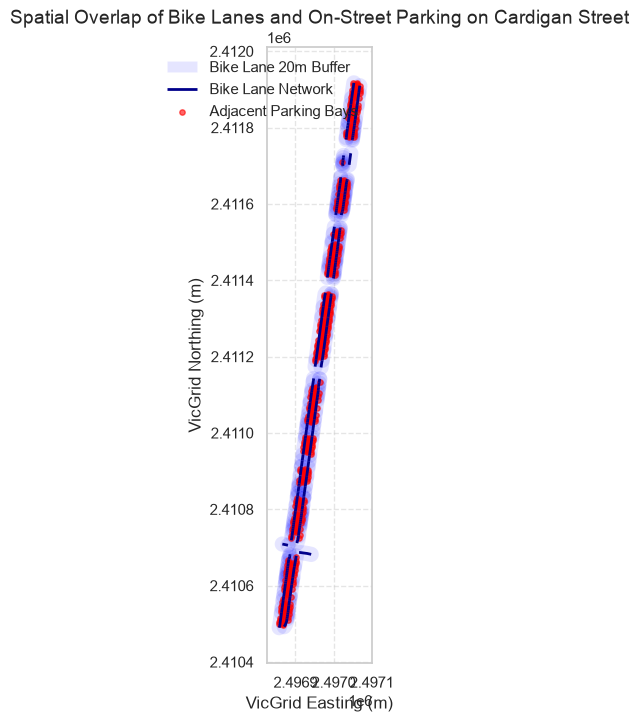

In [5]:
if 'matched' in locals() and not street_counts.empty:
    # Select the top street for visualization
    top_street = street_counts.sort_values(by="bay_id", ascending=False).iloc[0]["street_name"]
    print(f"Plotting spatial impacts for: {top_street}")

    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot buffer, bike lanes, and bays
    relevant_bike_ids = matched[matched['street_name'] == top_street]['objectid'].unique()
    
    gdf_bike_buffer[gdf_bike_buffer['objectid'].isin(relevant_bike_ids)].plot(
        ax=ax, color='blue', alpha=0.1, label='Bike Lane 20m Buffer'
    )
    gdf_bike_proj[gdf_bike_proj['objectid'].isin(relevant_bike_ids)].plot(
        ax=ax, color='darkblue', linewidth=2, label='Bike Lane Network'
    )
    gdf_bays_proj[gdf_bays_proj['street_name'] == top_street].plot(
        ax=ax, color='red', markersize=15, alpha=0.6, label='Adjacent Parking Bays'
    )

    plt.title(f"Spatial Overlap of Bike Lanes and On-Street Parking on {top_street}", fontsize=14)
    plt.xlabel("VicGrid Easting (m)")
    plt.ylabel("VicGrid Northing (m)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
